In [2]:
#!pip install ternary-diagram


  Obtaining dependency information for ternary-diagram from https://files.pythonhosted.org/packages/78/55/1b97ef34496d867b39a44b5b63f1615aafa068959fc5393ae8a2b8d9cba6/ternary_diagram-3.1.0-py3-none-any.whl.metadata


In [3]:
#!pip install mpltern

  Obtaining dependency information for mpltern from https://files.pythonhosted.org/packages/98/dd/4c47fa0119194e8343b27e19e5c1550c52435ba918d58c8a5319d899c302/mpltern-1.0.2-py3-none-any.whl.metadata


In [1]:
import mpltern as tern
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
modal_comp = pd.read_csv('Modal_composition.csv')
carbonate_comp = pd.read_csv('carbonate_composition.csv')
carbonate_comp

,Sample,calcite,dolomite,gypsum,total percentage
0,80823A,0.000,99.33,0,99.330
1,71923A,95.670,0.00,0,95.670
2,71923B,8.000,91.00,0,99.000
3,83123A,0.667,98.67,0,99.337


### Non-Soluble Ternary

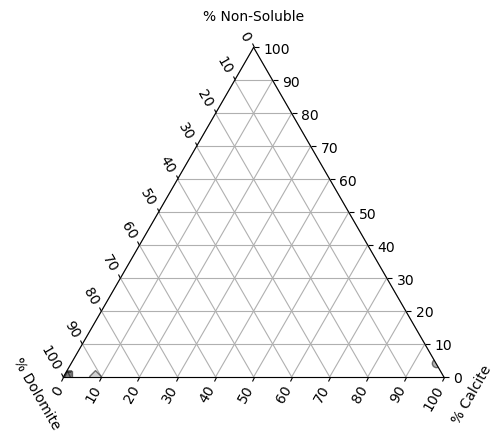

In [15]:
import numpy as np

import matplotlib.pyplot as plt
import mpltern

fig = plt.figure(figsize=(10.8, 4.8))
ax = fig.add_subplot(1, 2, 1, projection="ternary", zorder = 1)
ax.grid()

BMTC80823A = [(0.00667, .9933, 0.01)]
Omega71923A = [(.043, 0, .9567)]
Omega71923B = [(0.0033, 0.91, 0.08)]
Onon83123A = [(0.0067, .9867, 0.0067)]


# Unpack the points and plot them
ax.scatter(*zip(*BMTC80823A), color='Black', marker='s',  edgecolors= 'black', label='Bad Medicine - Tre Charros', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Omega71923A), color='dimgray', marker='o',  edgecolors= 'black', label='Omega Big Lime', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Omega71923B), color='darkgray', marker='D',  edgecolors= 'black', label='Omega Dolomite', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Onon83123A), color='gray', marker='^',  edgecolors= 'black', label='Onondaga', alpha= 0.5, zorder = 2)

ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
ax.taxis.set_ticks(ticks, labels=labels)
ax.laxis.set_ticks(ticks, labels=labels)
ax.raxis.set_ticks(ticks, labels=labels)

ax.set_tlabel('% Non-Soluble')
ax.set_rlabel('% Calcite')
ax.set_llabel('% Dolomite')

plt.savefig('non-soluble_ternary.png', dpi = 600)

plt.show()

### Non Soluble Spectrum

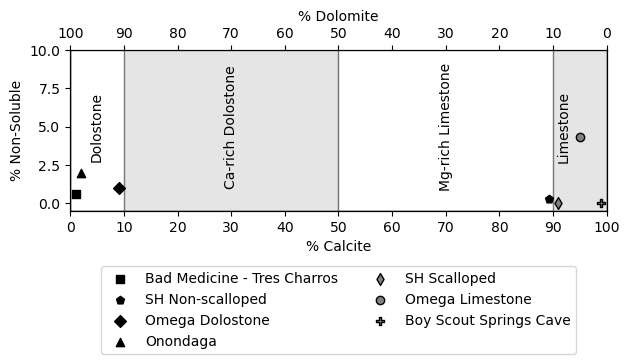

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

fig, ax = plt.subplots()
ax.set_ylim(-0.5, 10)
rectangle = plt.Rectangle((0, -0.5), 100, 100.5, edgecolor='black', facecolor='none')
ax.add_patch(rectangle)
ax_bottom = ax.twiny()
ax_bottom.set_xlim(100, 0)
ax_bottom.set_xticks(np.arange(100, -1, -10))
ax.set_xticks(np.arange(0, 101, 10))
ax.set_box_aspect(0.3)
ax_bottom.set_xlabel('% Dolomite')
ax.set_xlabel('% Calcite')
ax.set_ylabel('% Non-Soluble')

# Each x-value needs to be a dolomite concentration
BMTC80823A = (99, 0.6)
Omega71923A = ( 5, 4.3)
Omega71923B = (91, 1 )
Onon83123A = (98, 2)
LPSC = (9, 0.0) 
LPNS = (10.667, 0.3)
BSS90423 = (1, 0)


# Non-scalloped: Black 
# Scalloped: Gray

ax_bottom.scatter(*BMTC80823A, color='black', marker= 's', edgecolors= 'black', linewidth = 1,  label='Bad Medicine - Tres Charros')

ax_bottom.scatter(*LPNS, color = 'black', marker= 'p', edgecolors= 'Black', linewidths= 1, label = 'SH Non-scalloped' )


ax_bottom.scatter(*Omega71923B, color='black', marker = 'D', edgecolors= 'black', linewidth = 1, label='Omega Dolostone')

ax_bottom.scatter(*Onon83123A, color='black', marker = '^', edgecolors= 'black', linewidth = 1, label='Onondaga')

ax_bottom.scatter(*LPSC, color = 'gray', marker= 'd', edgecolors= 'Black', linewidths= 1, label = 'SH Scalloped' )

ax_bottom.scatter(*Omega71923A, color='gray', marker= 'o', edgecolors= 'black', linewidth = 1, label='Omega Limestone')

ax_bottom.scatter(*BSS90423, color = 'gray', marker = 'P', edgecolors= 'black', linewidths= 1, label = 'Boy Scout Springs Cave' )


# filled Region

Dolostone = patches.Rectangle((0, -0.5), 10, 10.5, edgecolor='black', facecolor='none', alpha=0.3)
Ca_rich_Dolostone = patches.Rectangle((10,-0.5), 40, 10.5, edgecolor='black', facecolor='darkgray', alpha=0.3 )
Mg_rich_Limestone = patches.Rectangle((50,-0.5),40, 10.5, edgecolor='black', facecolor='none', alpha=0.3)
Limestone = patches.Rectangle((90,-0.5),10, 10.5, edgecolor='black', facecolor='darkgray', alpha=0.3)
ax.add_patch(Dolostone)
ax.add_patch(Ca_rich_Dolostone)
ax.add_patch(Mg_rich_Limestone)
ax.add_patch(Limestone)

# Classification Labels

ax.text(5, 5, 'Dolostone', rotation = 90, va = 'center', ha = 'center')
ax.text(30, 5, 'Ca-rich Dolostone', rotation = 90, va = 'center', ha = 'center')
ax.text(70, 5, 'Mg-rich Limestone', rotation = 90, va = 'center', ha = 'center')
ax.text(92, 5, 'Limestone', rotation = 90, va = 'center', ha = 'center')

# Show the plot
plt.legend(loc = 'upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()

#plt.savefig('dolomite-calcite-spectrum.png', dpi = 300)
plt.show()


### Carbonate Ternary Diagram

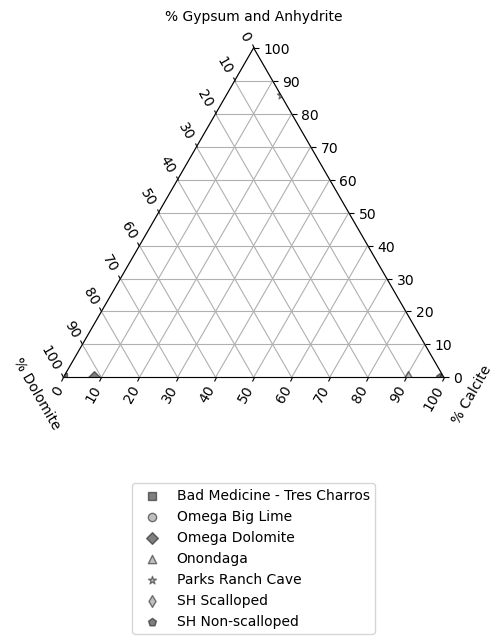

In [16]:
import numpy as np

import matplotlib.pyplot as plt
import mpltern

fig = plt.figure(figsize=(10.8, 4.8))
ax = fig.add_subplot(1, 2, 1, projection="ternary", zorder = 1)
ax.grid()

# Calcite, Dolomite, Gypsum, actual: Gypsum, dolomite, calcite
BMTC80823A = [(0, 99.33, 0 )]
Omega71923A = [(0, 0, 95.667)]
Omega71923B = [(0, 91, 8)]
Onon83123A = [(0 , 98.67, 0.0067)]
PRC111123A = [(83,0, 14)]
LPSC = [(0, 9.333, 90.667)]
LPNS = [(0, 1, 99 )]

# Unpack the points and plot them
ax.scatter(*zip(*BMTC80823A), color='black', marker='s',  edgecolors= 'black', label='Bad Medicine - Tres Charros', alpha= 0.5, zorder = 4)
ax.scatter(*zip(*Omega71923A), color='gray', marker='o',  edgecolors= 'black', label='Omega Big Lime', alpha= 0.5, zorder = 4)
ax.scatter(*zip(*Omega71923B), color='black', marker='D',  edgecolors= 'black', label='Omega Dolomite', alpha= 0.5, zorder =4)
ax.scatter(*zip(*Onon83123A), color='gray', marker='^',  edgecolors= 'black', label='Onondaga', alpha= 0.5, zorder = 4)
ax.scatter(*zip(*PRC111123A), color = 'gray', marker = '*', edgecolors= 'black', label = 'Parks Ranch Cave', alpha = 0.5, zorder = 4)
ax.scatter(*zip(*LPSC), color = 'gray', marker = 'd', edgecolors= 'black', label = 'SH Scalloped', alpha = 0.5, zorder = 4)
ax.scatter(*zip(*LPNS), color = 'black', marker = 'p', edgecolors= 'black', label = 'SH Non-scalloped', alpha = 0.5, zorder = 4)

ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
ax.taxis.set_ticks(ticks, labels=labels)
ax.laxis.set_ticks(ticks, labels=labels)
ax.raxis.set_ticks(ticks, labels=labels)

ax.set_tlabel('% Gypsum and Anhydrite')
ax.set_rlabel('% Calcite')
ax.set_llabel('% Dolomite')

plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.8))
plt.savefig('ternary_modal_plot.png', dpi = 600)

plt.show()

In [7]:
!pip install ternary
import numpy as np
import matplotlib.pyplot as plt
import ternary

# Define your data points as arrays
points = np.array([
    [0, 99.33, 0],
    [0, 0, 95.667],
    [0, 0.91, 8],
    [0, 0.9867, 0.0067],
    [83, 0, 14],
    [0, 9.333, 90.667],
    [0, 1, 99]
])

# Create a ternary plot
fig, tax = ternary.figure(scale=100)
tax.boundary(linewidth=2.0)
tax.gridlines(multiple=10, color="black")

# Plot data points on top of the ternary plot
tax.scatter(points, marker='o', color='gray', label='Data Points', s=50)

# Set axis labels
tax.set_title('% Gypsum and Anhydrite', fontsize=10)
tax.left_axis_label('% Dolomite', fontsize=10)
tax.right_axis_label('% Calcite', fontsize=10)

# Display the plot
plt.show()


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ternary: filename=ternary-0.1-py3-none-any.whl size=1766 sha256=299f4d5dac7a15da13ef91d89f9d337583533274ec56f1e721cbe8921049157b
  Stored in directory: c:\users\eoles\appdata\local\pip\cache\wheels\4c\7a\cf\5f7f85dd016b488190e35156da86a1fc2492af5576a4ca8c67
Successfully built ternary


AttributeError: module 'ternary' has no attribute 'figure'